# GPGPU in one hour — the demos, woven together

A 1-hour course for database & systems researchers. Every claim here is **measured on this machine**, not asserted. This notebook is the spine: it runs each demo and renders the numbers inline so the four theses land by evidence.

**Hardware reality.** The design spec targets H100/4090; this box has a single **RTX 6000 Ada** (sm_89, AD102, 48 GB **GDDR6** ≈ 960 GB/s, 96 MB L2, register file ≈ 36 MB) and an AMD Threadripper PRO 5945WX (DDR4-3200, NPS2). So "HBM" reads as GDDR6, and Demo 4's live hardware swap becomes a compile-time SASS diff. Everything else holds.

**The four theses (each demo must viscerally land at least one):**
1. A GPU is a **memory hierarchy with compute attached**, not "many cores." Bandwidth is its identity.
2. Per-core compute is mid; **per-memory-hierarchy** the GPU is a different *kind* of object.
3. **Kernel writing is ~10%** of GPU programming. Allocation, async, library composition are the rest.
4. The standard CUDA model is a **fiction** — the real chip exposes more than the model captures.

In [1]:
%matplotlib inline
import subprocess, re, os
import pandas as pd
import matplotlib.pyplot as plt

ROOT = os.getcwd()
GREEN, GREY, RED = "#76b900", "#888888", "#c0392b"

def sh(cmd, cwd=None, timeout=900):
    r = subprocess.run(cmd, shell=True, cwd=cwd or ROOT,
                       capture_output=True, text=True, timeout=timeout)
    return r.stdout + r.stderr

def grab(text, pat):
    m = re.search(pat, text)
    return float(m.group(1)) if m else float("nan")

print(sh("make all")[-200:] or "binaries up to date")

 Entering directory '/home/stargazermiao/workspace/gpu_course/demo3_rugpull'
make[1]: Nothing to be done for 'all'.
make[1]: Leaving directory '/home/stargazermiao/workspace/gpu_course/demo3_rugpull'



## Demo 1 — Bandwidth identity  *(thesis 1 & 2)*

A trivial streaming copy. The CPU's STREAM Triad tops out at ~60–75% of its (small) DRAM peak — limited by outstanding misses, not compute. The GPU's copy kernel saturates its (much larger) bus by design. The story is the **ratio**, and that the GPU number comes from a kernel you could write in your sleep.

GPU: NVIDIA RTX 6000 Ada Generation  (sm_89)
Buffer: 1.07 GB x2  | theoretical peak: 960 GB/s | L2: 101 MB

copy kernel:                810.9 GB/s  (84.5% of peak)
cudaMemcpy D2D:             799.7 GB/s  (83.3% of peak)

CPU STREAM Triad (double)
Threads: 6 | array: 0.64 GB x3 | best time: 50.817 ms
triad bandwidth:             37.8 GB/s
(divide by your per-node theoretical peak for % of peak)


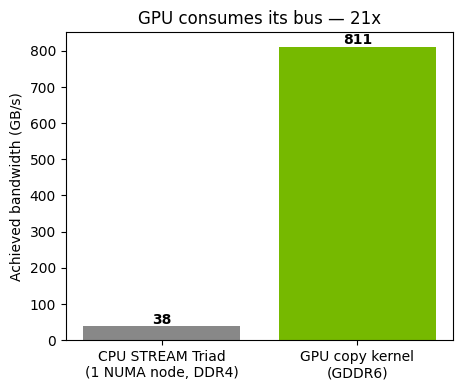

In [2]:
gpu_out = sh("./stream_gpu", cwd=f"{ROOT}/demo1_bandwidth")
numa = "numactl --cpunodebind=0 --membind=0 " if sh("which numactl").strip() else ""
cpu_out = sh(f"OMP_NUM_THREADS=6 OMP_PROC_BIND=close OMP_PLACES=cores {numa}./stream_cpu",
             cwd=f"{ROOT}/demo1_bandwidth")
print(gpu_out.strip()); print(); print(cpu_out.strip())

gpu = grab(gpu_out, r"copy kernel:\s*([\d.]+)")
cpu = grab(cpu_out, r"triad bandwidth:\s*([\d.]+)")
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(["CPU STREAM Triad\n(1 NUMA node, DDR4)", "GPU copy kernel\n(GDDR6)"],
       [cpu, gpu], color=[GREY, GREEN])
ax.set_ylabel("Achieved bandwidth (GB/s)")
ax.set_title(f"GPU consumes its bus — {gpu/cpu:.0f}x")
for i, v in enumerate([cpu, gpu]):
    ax.text(i, v, f"{v:.0f}", ha="center", va="bottom", fontweight="bold")
plt.show()

## Demo 2 — The sort optimization arc  *(the centerpiece, thesis 1→3)*

Bitonic sort is the teaching vehicle (data-oblivious, maps cleanly to shared memory and warp shuffles). **Production GPU sort is radix (CUB)** — v4 makes that explicit.

### 2a. First, the cache cliff — *why size matters*

Before any optimization: run the naive v0 across sizes. Cross the **96 MB L2** and throughput falls off a cliff. The same code, the same chip — the only thing that changed is whether the array fits in cache. *That* is thesis 1, before we write a single optimization. It's also why the arc runs at 2^26 (256 MB): so we measure HBM, not L2.

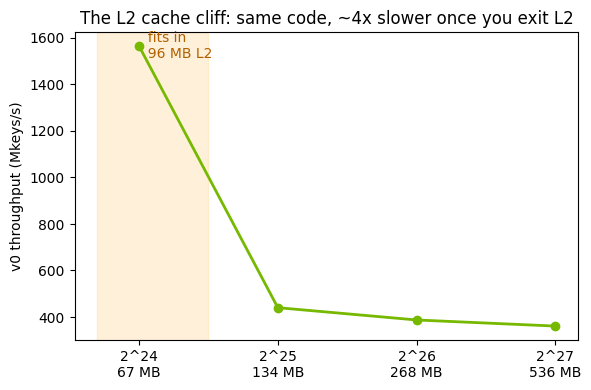

Mkeys/s by size: {'2^24': 1564, '2^25': 440, '2^26': 387, '2^27': 360}


In [3]:
sizes = [24, 25, 26, 27]
mk = [grab(sh(f"./v0_naive {L} 5", cwd=f"{ROOT}/demo2_sort"), r"([\d.]+)\s*Mkeys/s")
      for L in sizes]
x = list(range(len(sizes)))
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(x, mk, "o-", color=GREEN, lw=2)
ax.axvspan(-0.3, 0.5, color="orange", alpha=0.15)
ax.text(0, mk[0], "  fits in\n  96 MB L2", va="center", color="#b06000")
ax.set_xticks(x); ax.set_xticklabels([f"2^{s}\n{2**s*4//10**6} MB" for s in sizes])
ax.set_ylabel("v0 throughput (Mkeys/s)")
ax.set_title("The L2 cache cliff: same code, ~4x slower once you exit L2")
plt.show()
print("Mkeys/s by size:", {f"2^{s}": round(v) for s, v in zip(sizes, mk)})

### 2b. The arc — v0 → v4

Each step is one idea, measured on the identical 2^26 array (all verified against `std::sort`):

| step | idea | teaching point |
|---|---|---|
| **v0** | every stage in global memory | naive parallelism is bandwidth-*naive* |
| **v1** | small-stride stages in **shared memory** | the programmable scratchpad is the GPU's signature |
| **v2** | innermost stages via **warp shuffle** | the register file is your fastest memory (and you can address a neighbor's) |
| **v3** | bigger tile → **fewer global passes** | grid-level structure is where it gets architecturally interesting |
| **v4** | **CUB radix** | production GPU code is library composition, not kernel writing |

The real lever on a bandwidth machine: **how many times you stream the array.** v0 ≈ 351 passes, v3 ≈ 104 (the bitonic roofline), CUB ≈ 4–8.

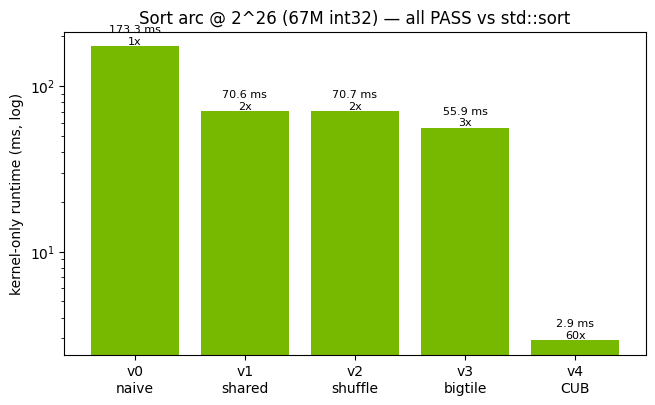

In [4]:
ARC = ["v0_naive", "v1_shared", "v2_shuffle", "v3_multiblock", "v4_cub"]
LAB = {"v0_naive": "v0\nnaive", "v1_shared": "v1\nshared", "v2_shuffle": "v2\nshuffle",
       "v3_multiblock": "v3\nbigtile", "v4_cub": "v4\nCUB"}
ms = {v: grab(sh(f"./{v} 26 10", cwd=f"{ROOT}/demo2_sort"), r"([\d.]+)\s*ms") for v in ARC}
base = ms["v0_naive"]
fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar([LAB[v] for v in ARC], [ms[v] for v in ARC], color=GREEN)
ax.set_yscale("log"); ax.set_ylabel("kernel-only runtime (ms, log)")
ax.set_title("Sort arc @ 2^26 (67M int32) — all PASS vs std::sort")
for v, b in zip(ARC, bars):
    ax.text(b.get_x()+b.get_width()/2, ms[v], f"{ms[v]:.1f} ms\n{base/ms[v]:.0f}x",
            ha="center", va="bottom", fontsize=8)
plt.show()

### 2c. v2's win is invisible on the stopwatch — and obvious in the profiler

v2 (warp shuffle) is ~flat in wall-clock: it speeds up the shared-memory `local_merge` but that's only ~14% of the time — the wide-stride `global_stage` passes dominate. This is **Amdahl's law, live**: you optimized something real, but not the bottleneck, and the profiler proves both halves of that sentence. (Loaded from `run_ncu.sh` output.)

In [5]:
csv = f"{ROOT}/slides/figs/sort_kernel_metrics.csv"
if os.path.exists(csv):
    d = pd.read_csv(csv)
    lm = d[d.kernel.str.contains("local_merge")].copy()
    cols = ["version", "dur_ms", "dram_pct", "occ_pct", "stall_shared", "stall_barrier"]
    lm = lm[[c for c in cols if c in lm.columns]].reset_index(drop=True)
    print("local_merge kernel — v1 vs v2 vs v3 (warp shuffle cuts shared + barrier stalls):")
    display(lm.round(2))
else:
    print("Run:  cd profile && ./run_ncu.sh && python3 extract_metrics.py")

local_merge kernel — v1 vs v2 vs v3 (warp shuffle cuts shared + barrier stalls):


,version,dur_ms,dram_pct,occ_pct,stall_shared,stall_barrier
0,v1_shared,1.15,46.73,65.28,3.97,5.94
1,v2_shuffle,0.98,55.00,64.19,3.16,4.47
2,v3_multiblock,1.04,51.51,65.89,1.83,1.56


## Demo 3 — The rug pull  *(thesis 3: the kernel is 10%)*

Take the best hand-rolled sort (v3) and wrap it the way a query stage actually appears in a pipeline: allocate, copy in, sort, copy out, free — every iteration. The kernel never changes. Watch what the *orchestration* costs, and how `cudaMallocAsync` (a memory pool) and a CUDA graph claw it back.

naive (cudaMalloc/Free per iter)  n=2^20  iters=200  [PASS]
pool (cudaMallocAsync per iter)  n=2^20  iters=200  [PASS]
graph (capture once, replay)  n=2^20  iters=200  [PASS]


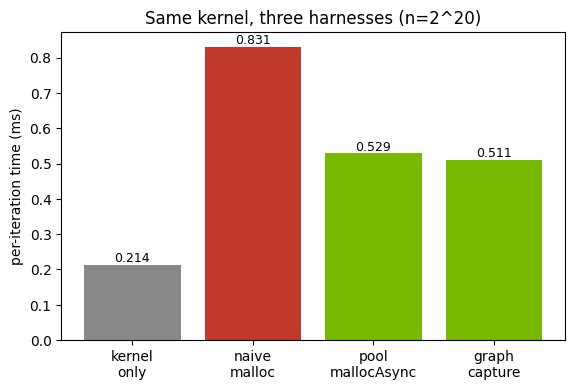


nsys CUDA-API time (the driver round-trip is the villain):
  naive : naive (cudaMalloc/Free per iter)  n=2^20  iters=30  [PASS]
  pool  : pool (cudaMallocAsync per iter)  n=2^20  iters=30  [PASS]


In [6]:
H = ["naive", "pool", "graph"]
outs = {h: sh(f"./{h}_harness 20 200", cwd=f"{ROOT}/demo3_rugpull") for h in H}
pit = {h: grab(outs[h], r"per-iter\s*:\s*([\d.]+)") for h in H}
kon = grab(outs["naive"], r"kernel-only\s*:\s*([\d.]+)")
for h in H: print(outs[h].strip().splitlines()[0])

fig, ax = plt.subplots(figsize=(6.5, 4))
labels = ["kernel\nonly", "naive\nmalloc", "pool\nmallocAsync", "graph\ncapture"]
vals = [kon, pit["naive"], pit["pool"], pit["graph"]]
ax.bar(labels, vals, color=[GREY, RED, GREEN, GREEN])
ax.set_ylabel("per-iteration time (ms)")
ax.set_title("Same kernel, three harnesses (n=2^20)")
for i, v in enumerate(vals):
    ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.show()

st_n = f"{ROOT}/profile/nsys_out/stats_naive.txt"
st_p = f"{ROOT}/profile/nsys_out/stats_pool.txt"
if os.path.exists(st_n) and os.path.exists(st_p):
    def api_avg(path, name):
        for ln in open(path):
            if name in ln:
                nums = re.findall(r"[\d,]+\.?\d*", ln)
                return ln.strip()
        return None
    print("\nnsys CUDA-API time (the driver round-trip is the villain):")
    print("  naive :", api_avg(st_n, "cudaMalloc"))
    print("  pool  :", api_avg(st_p, "cudaMallocAsync"))

## Demo 4 — The chip is bigger than the model  *(thesis 4)*

Only one GPU here, so no live hardware swap. The compile-time version is arguably sharper: take the **same source** and compile it for Ada (sm_89) and Hopper (sm_90). The machine code differs — ptxas exploits instructions that don't exist on the older arch. You wrote `min()/max()`; on Hopper it becomes `VIMNMX`. CUB goes further and **ships entirely different kernels per architecture**, emitting Hopper *collective* instructions the CUDA C model never surfaces.

What we *can't* show without the hardware: live Hopper bandwidth/occupancy, and anything using TMA/DSMEM/clusters (those would appear only in this disassembly, never run). (Loaded from `demo4_hwswap/run_all.sh` output.)

In [7]:
so = f"{ROOT}/demo4_hwswap/sass_out"
if os.path.isdir(so) and os.path.exists(f"{so}/v3_multiblock_ops90.txt"):
    for v, note in [("v3_multiblock", "our hand-rolled sort"), ("v4_cub", "CUB radix")]:
        a = set(open(f"{so}/{v}_ops89.txt").read().split())
        b = set(open(f"{so}/{v}_ops90.txt").read().split())
        print(f"{v}  ({note})")
        print(f"   sm_90-only opcodes: {', '.join(sorted(b - a))}")
        print(f"   sm_89-only opcodes: {', '.join(sorted(a - b))}\n")
else:
    print("Run:  cd demo4_hwswap && ./run_all.sh")

v3_multiblock  (our hand-rolled sort)
   sm_90-only opcodes: LDC, LDC.64, MOV, P2R, S2UR, ULEA, UMOV, VIADD, VIMNMX
   sm_89-only opcodes: IMNMX, ISETP.EQ.XOR

v4_cub  (CUB radix)
   sm_90-only opcodes: CS2R, ENDCOLLECTIVE, HFMA2.MMA, LDC, LDC.64, REDG.E.ADD.STRONG.GPU, UISETP.GT.AND, VIADD, VIMNMX, WARPSYNC.ALL, WARPSYNC.COLLECTIVE, WARPSYNC.EXCLUSIVE
   sm_89-only opcodes: CALL.REL.NOINC, IMNMX, ISETP.EQ.U32.AND, RED.E.ADD.STRONG.GPU, REDUX.OR, RET.REL.NODEC, WARPSYNC



## Closing — the four theses, by the numbers

- **Bandwidth is identity.** A trivial copy hit ~84% of GDDR6 peak; the CPU, tuned, reached its DRAM ceiling at a fraction of the absolute number. *(Demo 1)*
- **The GPU is a different kind of object per memory hierarchy.** The cache cliff, the scratchpad, the register-file shuffle — the whole sort arc was memory-hierarchy engineering, not "more cores." *(Demo 2)*
- **The kernel is ~10%.** A fully-tuned kernel, wrapped naively, lost most of its speed to allocation and orchestration — recovered by a memory pool and a graph, not by touching the kernel. *(Demo 3)*
- **The model is a fiction.** The same source compiled to different machine code per architecture; the library shipped per-arch kernels using instructions the model doesn't expose. *(Demo 4)*

And the through-line: **on a bandwidth machine, sorting performance is the number of times you stream the array.** v0 streamed it ~351×; CUB ~4–8×. Everything in between was learning to stream it fewer times.